In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [3]:
df = pd.read_excel(r"C:\Users\ASUS\OneDrive\Desktop\baki_emlak_data.xlsx", sheet_name="Sheet1")
print(f"Sətir sayı: {df.shape[0]}, Sütun sayı: {df.shape[1]}")
df.head()

Sətir sayı: 60, Sütun sayı: 20


,Elan_ID,Rayon,Metro_Stansiyası,Metroya_Məsafə_dəq,Bina_Növü,Tikinti_İli,Bina_Yaşı,Otaq_Sayı,Sahə_m2,Mərtəbə,Binanın_Mərtəbəsi,Təmir_Növü,Dayanacaq,Çıxarış,Qiymət_m2_AZN,Satış_Qiyməti_AZN,Kirayə_Qiyməti_AZN,Kommunal_Xərclər_AZN,Elan_Tarixi,Satışda_Qalma_Günü
0,BN1001,Yasamal,Ulduz,5,Yeni tikili,2006,19,1,46.6,11,16,Təmirsiz,Var,Var,1501,69900,300,90,2024-04-24,8
1,BN1002,Abşeron,Avtovağzal,11,Yeni tikili,2012,13,1,51.7,8,16,Təmirsiz,Yoxdur,Var,881,45500,210,105,2024-02-02,8
2,BN1003,Abşeron,Xocəsən,11,Yeni tikili,2022,3,2,64.9,16,24,Orta,Var,Var,1048,68000,310,125,2024-02-07,12
3,BN1004,Suraxanı,Q.Qarayev,5,Yeni tikili,2015,10,1,45.8,7,9,Təmirsiz,Var,Var,997,45700,250,100,2024-02-17,22
4,BN1005,Sabunçu,Terminal,22,Köhnə tikili,1965,60,3,88.8,5,9,Yaxşı,Yoxdur,Var,1208,107300,510,160,2024-03-07,45


In [4]:
print("Boş dəyərlər:\n", df.isnull().sum().sum(), "ədəd")
print("\nDublikat Elan_ID:", df["Elan_ID"].duplicated().sum())

Boş dəyərlər:
 0 ədəd

Dublikat Elan_ID: 0


In [5]:
numeric_cols = ["Metroya_Məsafə_dəq", "Bina_Yaşı", "Otaq_Sayı", "Sahə_m2",
                 "Qiymət_m2_AZN", "Satış_Qiyməti_AZN", "Kirayə_Qiyməti_AZN",
                 "Satışda_Qalma_Günü"]

for col in numeric_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    if len(outliers) > 0:
        print(f"{col}: {len(outliers)} outlier (sərhəd: {lower:.1f} - {upper:.1f})")

Otaq_Sayı: 5 outlier (sərhəd: 0.5 - 4.5)
Sahə_m2: 8 outlier (sərhəd: 18.7 - 138.3)
Satış_Qiyməti_AZN: 2 outlier (sərhəd: -39825.0 - 283175.0)
Kirayə_Qiyməti_AZN: 2 outlier (sərhəd: -286.2 - 1483.8)
Satışda_Qalma_Günü: 1 outlier (sərhəd: -42.4 - 142.6)


In [6]:
desc = df[numeric_cols].describe().T
desc["skewness"] = df[numeric_cols].skew()
desc["kurtosis"] = df[numeric_cols].kurt()
print(desc.round(2))

                    count       mean       std      min       25%       50%  \
Metroya_Məsafə_dəq   60.0      12.37      9.44      2.0      5.00      10.0   
Bina_Yaşı            60.0      25.80     17.74      1.0     12.00      20.0   
Otaq_Sayı            60.0       2.53      1.13      1.0      2.00       2.0   
Sahə_m2              60.0      84.84     32.72     39.6     63.58      78.9   
Qiymət_m2_AZN        60.0    1468.30    512.83    658.0   1047.25    1420.5   
Satış_Qiyməti_AZN    60.0  125538.33  69776.81  27000.0  81300.00  106550.0   
Kirayə_Qiyməti_AZN   60.0     633.33    378.22    130.0    377.50     505.0   
Satışda_Qalma_Günü   60.0      55.33     36.23      8.0     27.00      46.0   

                          75%       max  skewness  kurtosis  
Metroya_Məsafə_dəq      17.25      35.0      1.01     -0.02  
Bina_Yaşı               40.50      60.0      0.46     -1.06  
Otaq_Sayı                3.00       5.0      0.72     -0.07  
Sahə_m2                 93.48     170.8 

In [9]:
for col in ["Rayon", "Bina_Növü", "Təmir_Növü", "Dayanacaq", "Çıxarış"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


--- Rayon ---
Rayon
Sabail          8
Binəqədi        7
Xətai           6
Nəsimi          6
Həzi Aslanov    5
Pirəkəşkul      5
Abşeron         5
Suraxanı        4
Nizami          4
Sabunçu         4
Yasamal         3
Nərimanov       3
Name: count, dtype: int64

--- Bina_Növü ---
Bina_Növü
Yeni tikili     32
Köhnə tikili    28
Name: count, dtype: int64

--- Təmir_Növü ---
Təmir_Növü
Təmirsiz    22
Yaxşı       16
Əla         12
Orta        10
Name: count, dtype: int64

--- Dayanacaq ---
Dayanacaq
Yoxdur    38
Var       22
Name: count, dtype: int64

--- Çıxarış ---
Çıxarış
Var       50
Yoxdur    10
Name: count, dtype: int64


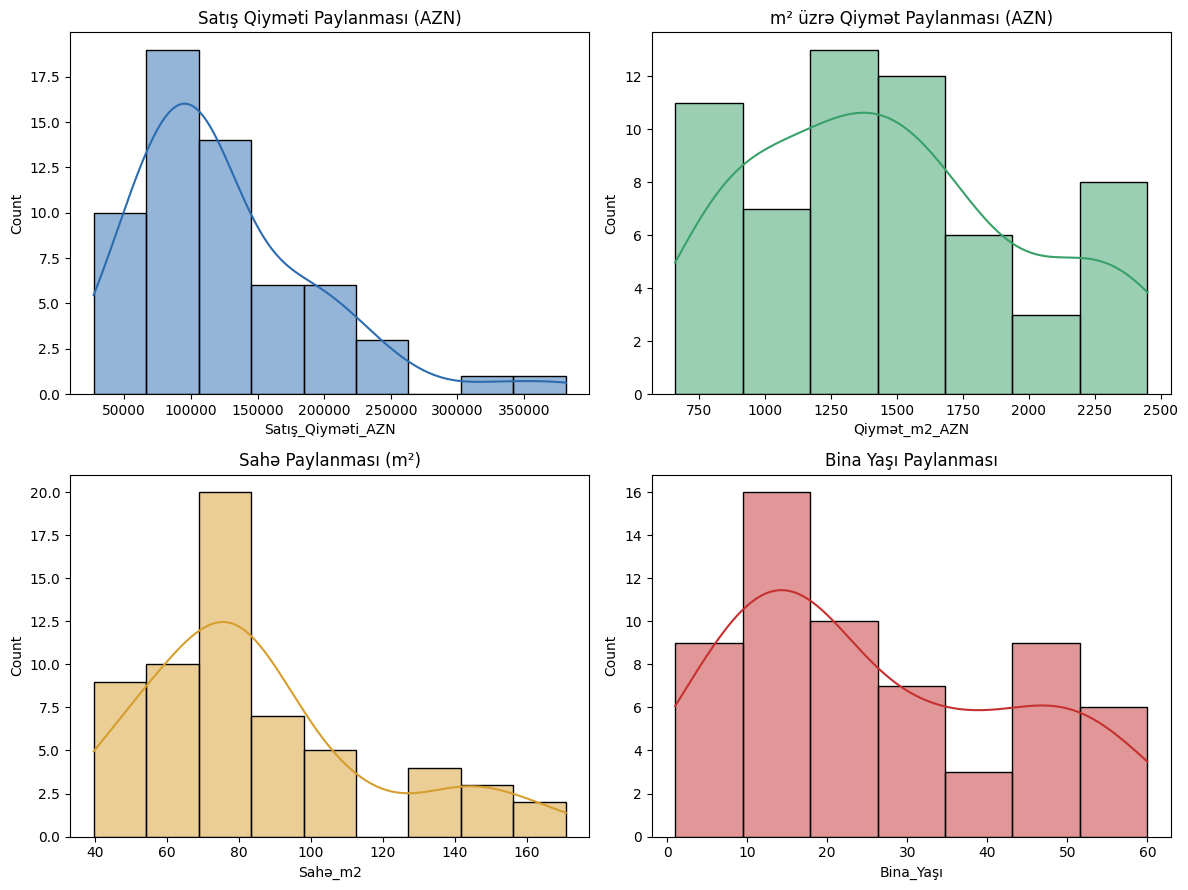

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
sns.histplot(df["Satış_Qiyməti_AZN"], kde=True, ax=axes[0, 0], color="#2b6cb0")
axes[0, 0].set_title("Satış Qiyməti Paylanması (AZN)")

sns.histplot(df["Qiymət_m2_AZN"], kde=True, ax=axes[0, 1], color="#38a169")
axes[0, 1].set_title("m² üzrə Qiymət Paylanması (AZN)")

sns.histplot(df["Sahə_m2"], kde=True, ax=axes[1, 0], color="#d69e2e")
axes[1, 0].set_title("Sahə Paylanması (m²)")

sns.histplot(df["Bina_Yaşı"], kde=True, ax=axes[1, 1], color="#c53030")
axes[1, 1].set_title("Bina Yaşı Paylanması")

plt.tight_layout()
plt.show()

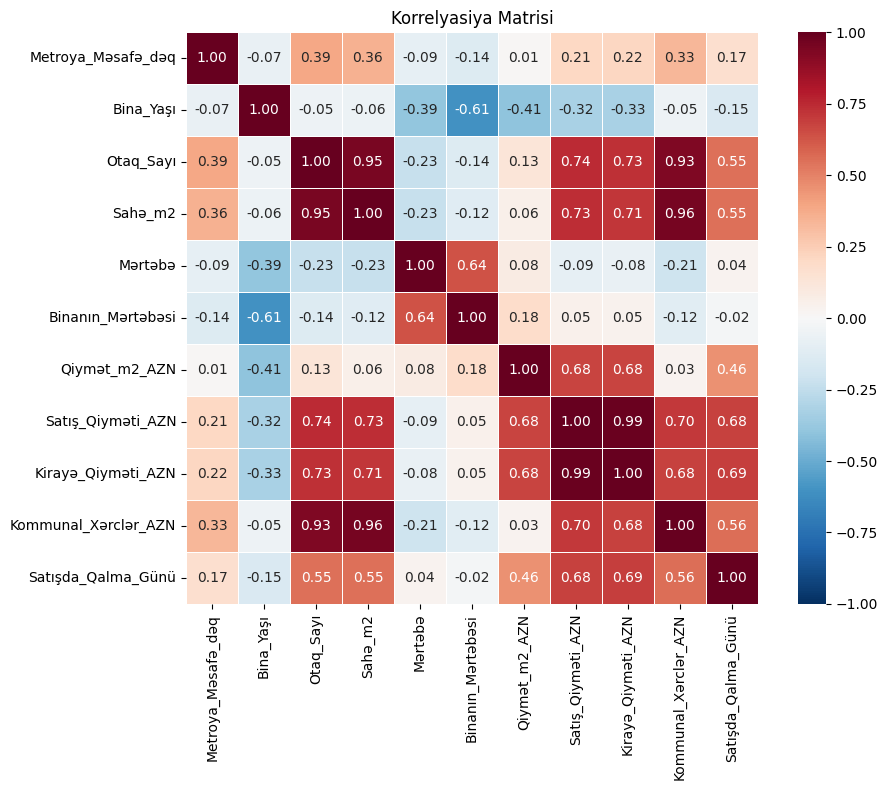

In [10]:
corr_cols = ["Metroya_Məsafə_dəq", "Bina_Yaşı", "Otaq_Sayı", "Sahə_m2",
             "Mərtəbə", "Binanın_Mərtəbəsi", "Qiymət_m2_AZN",
             "Satış_Qiyməti_AZN", "Kirayə_Qiyməti_AZN", "Kommunal_Xərclər_AZN",
             "Satışda_Qalma_Günü"]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Korrelyasiya Matrisi")
plt.tight_layout()
plt.show()

In [11]:
price_corr = corr_matrix["Satış_Qiyməti_AZN"].drop("Satış_Qiyməti_AZN").sort_values(key=abs, ascending=False)
print("Satış_Qiyməti_AZN ilə korrelyasiyalar (gücünə görə sıralı):")
print(price_corr.round(3))

r, p = stats.pearsonr(df["Sahə_m2"], df["Satış_Qiyməti_AZN"])
print(f"\nSahə_m2 vs Satış_Qiyməti_AZN: r={r:.3f}, p-value={p:.5f}")
print("Nəticə:", "statistik mənalıdır (p<0.05)" if p < 0.05 else "mənalı deyil")

Satış_Qiyməti_AZN ilə korrelyasiyalar (gücünə görə sıralı):
Kirayə_Qiyməti_AZN      0.986
Otaq_Sayı               0.743
Sahə_m2                 0.735
Kommunal_Xərclər_AZN    0.704
Satışda_Qalma_Günü      0.681
Qiymət_m2_AZN           0.679
Bina_Yaşı              -0.324
Metroya_Məsafə_dəq      0.208
Mərtəbə                -0.088
Binanın_Mərtəbəsi       0.049
Name: Satış_Qiyməti_AZN, dtype: float64

Sahə_m2 vs Satış_Qiyməti_AZN: r=0.735, p-value=0.00000
Nəticə: statistik mənalıdır (p<0.05)


In [12]:
yeni = df[df["Bina_Növü"] == "Yeni tikili"]["Qiymət_m2_AZN"]
kohne = df[df["Bina_Növü"] == "Köhnə tikili"]["Qiymət_m2_AZN"]

levene_stat, levene_p = stats.levene(yeni, kohne)
equal_var = levene_p > 0.05

t_stat, p_val = stats.ttest_ind(yeni, kohne, equal_var=equal_var)

print(f"Yeni tikili: n={len(yeni)}, ortalama={yeni.mean():.1f} AZN/m², std={yeni.std():.1f}")
print(f"Köhnə tikili: n={len(kohne)}, ortalama={kohne.mean():.1f} AZN/m², std={kohne.std():.1f}")
print(f"\nLevene testi: p={levene_p:.4f} -> {'bərabər dispersiya' if equal_var else 'qeyri-bərabər dispersiya'}")
print(f"T-statistika: {t_stat:.3f}, p-dəyər: {p_val:.5f}")
print("Nəticə:", "H0 rədd edilir — fərq statistik mənalıdır (p<0.05)" if p_val < 0.05
      else "H0 rədd edilmir — fərq statistik mənalı deyil")

pooled_std = np.sqrt(((len(yeni)-1)*yeni.std()**2 + (len(kohne)-1)*kohne.std()**2) / (len(yeni)+len(kohne)-2))
cohens_d = (yeni.mean() - kohne.mean()) / pooled_std
print(f"Cohen's d (effect size): {cohens_d:.3f}")

Yeni tikili: n=32, ortalama=1666.2 AZN/m², std=513.3
Köhnə tikili: n=28, ortalama=1242.1 AZN/m², std=415.6

Levene testi: p=0.1667 -> bərabər dispersiya
T-statistika: 3.484, p-dəyər: 0.00095
Nəticə: H0 rədd edilir — fərq statistik mənalıdır (p<0.05)
Cohen's d (effect size): 0.902


In [13]:
groups_rayon = [group["Satış_Qiyməti_AZN"].values for name, group in df.groupby("Rayon")]
f_stat, p_val_anova = stats.f_oneway(*groups_rayon)

print(f"ANOVA (Rayon -> Satış_Qiyməti_AZN): F={f_stat:.3f}, p-dəyər={p_val_anova:.5f}")
print("Nəticə:", "H0 rədd edilir — rayonlar arasında mənalı fərq var (p<0.05)" if p_val_anova < 0.05
      else "H0 rədd edilmir — rayonlar arasında mənalı fərq yoxdur")

print("\nRayon üzrə ortalama satış qiyməti:")
print(df.groupby("Rayon")["Satış_Qiyməti_AZN"].agg(["mean", "std", "count"]).sort_values("mean", ascending=False).round(0))

ANOVA (Rayon -> Satış_Qiyməti_AZN): F=5.853, p-dəyər=0.00001
Nəticə: H0 rədd edilir — rayonlar arasında mənalı fərq var (p<0.05)

Rayon üzrə ortalama satış qiyməti:
                  mean       std  count
Rayon                                  
Nərimanov     272267.0  146015.0      3
Nizami        178650.0   54415.0      4
Nəsimi        176467.0   58679.0      6
Xətai         166350.0   48347.0      6
Sabail        136475.0   44479.0      8
Həzi Aslanov  127680.0   51105.0      5
Yasamal        87633.0   21259.0      3
Binəqədi       85371.0   27809.0      7
Sabunçu        82075.0   32813.0      4
Pirəkəşkul     80760.0   35952.0      5
Abşeron        73500.0   20953.0      5
Suraxanı       63425.0   27520.0      4


C:\Users\ASUS\AppData\Local\Temp\ipykernel_22864\693590382.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Rayon", y="Satış_Qiyməti_AZN", order=order, palette="viridis")


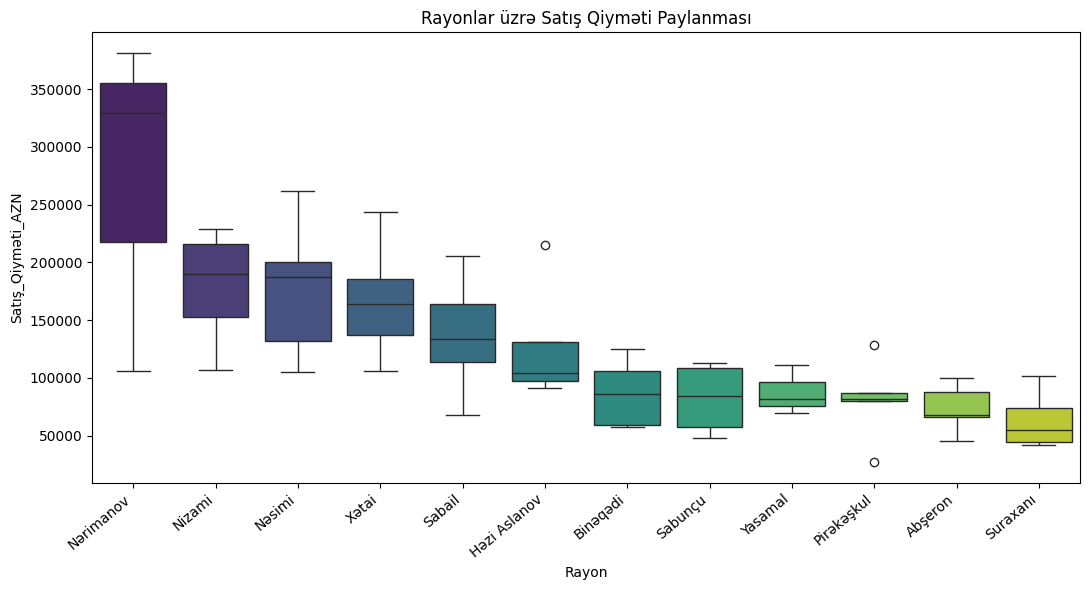

In [14]:
plt.figure(figsize=(11, 6))
order = df.groupby("Rayon")["Satış_Qiyməti_AZN"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="Rayon", y="Satış_Qiyməti_AZN", order=order, palette="viridis")
plt.xticks(rotation=40, ha="right")
plt.title("Rayonlar üzrə Satış Qiyməti Paylanması")
plt.tight_layout()
plt.savefig("3_rayon_boxplot.png", bbox_inches="tight")
plt.show()

In [15]:
groups_temir = [group["Qiymət_m2_AZN"].values for name, group in df.groupby("Təmir_Növü")]
f_stat2, p_val2 = stats.f_oneway(*groups_temir)

print(f"ANOVA (Təmir_Növü -> Qiymət_m2_AZN): F={f_stat2:.3f}, p-dəyər={p_val2:.5f}")
print("Nəticə:", "H0 rədd edilir — təmir növü qiymətə mənalı təsir edir (p<0.05)" if p_val2 < 0.05
      else "H0 rədd edilmir")

print("\nTəmir növü üzrə ortalama m² qiyməti:")
print(df.groupby("Təmir_Növü")["Qiymət_m2_AZN"].agg(["mean", "std", "count"]).round(0))

ANOVA (Təmir_Növü -> Qiymət_m2_AZN): F=12.776, p-dəyər=0.00000
Nəticə: H0 rədd edilir — təmir növü qiymətə mənalı təsir edir (p<0.05)

Təmir növü üzrə ortalama m² qiyməti:
              mean    std  count
Təmir_Növü                      
Orta        1370.0  455.0     10
Təmirsiz    1122.0  335.0     22
Yaxşı       1616.0  355.0     16
Əla         1987.0  531.0     12


In [16]:
if p_val2 < 0.05:
    from statsmodels.stats.multicomp import pairwise_tukeyhsd
    tukey = pairwise_tukeyhsd(df["Qiymət_m2_AZN"], df["Təmir_Növü"])
    print("\nTukey HSD post-hoc test:")
    print(tukey)


Tukey HSD post-hoc test:
     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
 group1   group2   meandiff p-adj    lower     upper   reject
-------------------------------------------------------------
    Orta Təmirsiz -247.8909 0.3855 -657.4709  161.6891  False
    Orta    Yaxşı    245.95 0.4418 -186.9641  678.8641  False
    Orta      Əla  616.5333 0.0043   156.705 1076.3617   True
Təmirsiz    Yaxşı  493.8409 0.0027  140.9865  846.6953   True
Təmirsiz      Əla  864.4242    0.0  479.0235  1249.825   True
   Yaxşı      Əla  370.5833 0.0902  -39.5296  780.6963  False
-------------------------------------------------------------


In [17]:
model_df = df.copy()

formula = ("Satış_Qiyməti_AZN ~ Sahə_m2 + Otaq_Sayı + Bina_Yaşı + Metroya_Məsafə_dəq "
           "+ Mərtəbə + C(Bina_Növü) + C(Təmir_Növü) + C(Dayanacaq) + C(Çıxarış)")

model = smf.ols(formula=formula, data=model_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      Satış_Qiyməti_AZN   R-squared:                       0.799
Model:                            OLS   Adj. R-squared:                  0.753
Method:                 Least Squares   F-statistic:                     17.35
Date:                Mon, 03 Aug 2026   Prob (F-statistic):           3.62e-13
Time:                        18:00:39   Log-Likelihood:                -705.68
No. Observations:                  60   AIC:                             1435.
Df Residuals:                      48   BIC:                             1460.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [18]:
X_num = model_df[["Sahə_m2", "Otaq_Sayı", "Bina_Yaşı", "Metroya_Məsafə_dəq", "Mərtəbə"]]
X_num = sm.add_constant(X_num)
vif_data = pd.DataFrame()
vif_data["dəyişən"] = X_num.columns
vif_data["VIF"] = [variance_inflation_factor(X_num.values, i) for i in range(X_num.shape[1])]
print("\nVariance Inflation Factor (VIF) — 5-10-dan yuxarı olarsa multikollinearlik şübhəlidir:")
print(vif_data.round(2))


Variance Inflation Factor (VIF) — 5-10-dan yuxarı olarsa multikollinearlik şübhəlidir:
              dəyişən    VIF
0               const  20.82
1             Sahə_m2  10.61
2           Otaq_Sayı  10.85
3           Bina_Yaşı   1.22
4  Metroya_Məsafə_dəq   1.18
5             Mərtəbə   1.28


In [20]:
pvalues = model.pvalues.drop("Intercept")
significant_vars = pvalues[pvalues < 0.10].index.tolist()
print("p<0.10 olan dəyişənlər:", significant_vars)

formula2 = ("Qiymət_m2_AZN ~ Bina_Yaşı + Metroya_Məsafə_dəq + C(Bina_Növü) "
            "+ C(Təmir_Növü) + C(Dayanacaq)")
model2 = smf.ols(formula=formula2, data=model_df).fit()
print(model2.summary())

p<0.10 olan dəyişənlər: ['C(Bina_Növü)[T.Yeni tikili]', 'C(Təmir_Növü)[T.Əla]', 'C(Çıxarış)[T.Yoxdur]', 'Sahə_m2']
                            OLS Regression Results                            
Dep. Variable:          Qiymət_m2_AZN   R-squared:                       0.517
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     7.948
Date:                Mon, 03 Aug 2026   Prob (F-statistic):           1.56e-06
Time:                        18:01:42   Log-Likelihood:                -437.20
No. Observations:                  60   AIC:                             890.4
Df Residuals:                      52   BIC:                             907.2
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]

C:\Users\ASUS\AppData\Local\Temp\ipykernel_22864\3614516906.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Təmir_Növü", y="Qiymət_m2_AZN",


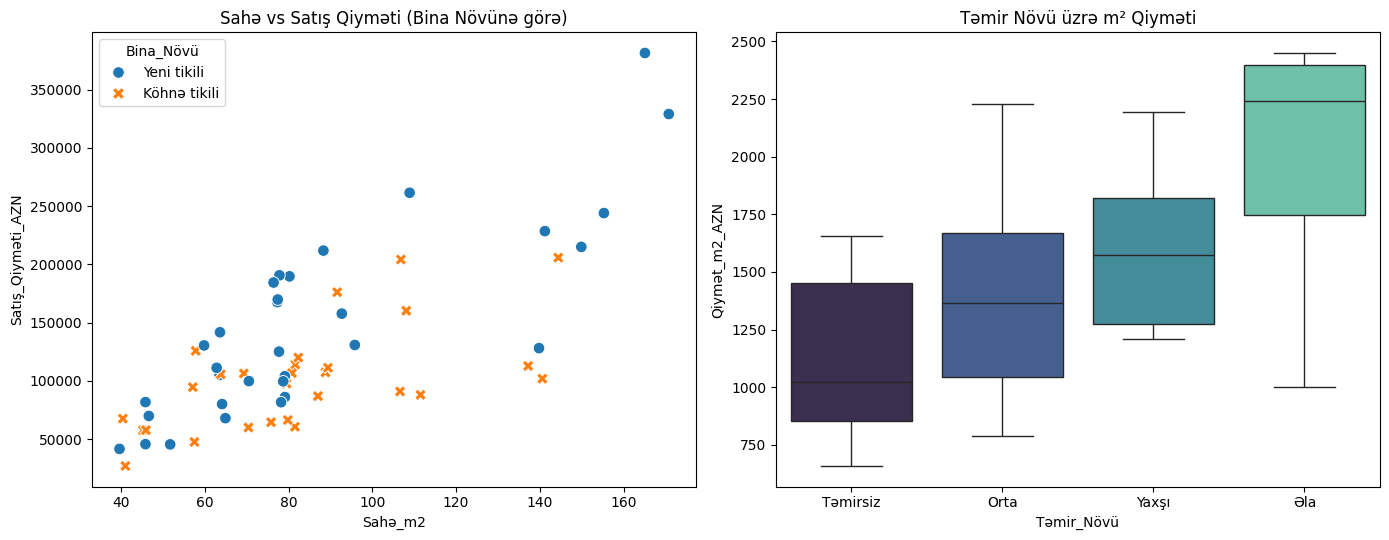

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.scatterplot(data=df, x="Sahə_m2", y="Satış_Qiyməti_AZN", hue="Bina_Növü",
                 style="Bina_Növü", s=70, ax=axes[0])
axes[0].set_title("Sahə vs Satış Qiyməti (Bina Növünə görə)")

sns.boxplot(data=df, x="Təmir_Növü", y="Qiymət_m2_AZN",
            order=["Təmirsiz", "Orta", "Yaxşı", "Əla"], palette="mako", ax=axes[1])
axes[1].set_title("Təmir Növü üzrə m² Qiyməti")

plt.tight_layout()
plt.show()